## Cell 1 – Import thư viện & Cấu hình (Nâng cấp)

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # MỚI: Dùng để vẽ Heatmap và biểu đồ phân tích lỗi đẹp hơn
from sklearn.preprocessing import MinMaxScaler
# Các thư viện tiền xử lý và đánh giá
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit # MỚI: Để xử lý Vấn đề #3 (Cross-Validation)

# Các mô hình Machine Learning
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Cấu hình hệ thống
import warnings
warnings.filterwarnings("ignore")

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)  # MỚI: Hiển thị hết cột để kiểm tra Feature Engineering
plt.style.use('seaborn-v0_8-whitegrid')     # MỚI: Style đồ thị chuẩn khoa học
plt.rcParams['figure.figsize'] = (12, 6)    # Tăng kích thước hình mặc định

RANDOM_STATE = 42

def print_section(title: str):
    print("\n" + "="*80)
    print(title.upper())
    print("="*80 + "\n")

print_section("1. IMPORT THƯ VIỆN & CẤU HÌNH HOÀN TẤT")


1. IMPORT THƯ VIỆN & CẤU HÌNH HOÀN TẤT



## cell 2

In [16]:
print("2. ĐỌC DỮ LIỆU & TẠO ĐẶC TRƯNG NÂNG CAO (FIXED LEAKAGE)")

DATA_PATH = "..//Data_clean//CA_Weather_Fire_Dataset_1984-2025_clean.csv"

# 1. Đọc dữ liệu & Sắp xếp
df = pd.read_csv(DATA_PATH, parse_dates=["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

print("Kích thước ban đầu:", df.shape)

# Nhãn: 1 = có cháy, 0 = không cháy
df["FIRE_LABEL"] = df["FIRE_START_DAY"].astype(int)

# ===================================================================
#                FEATURE ENGINEERING NÂNG CAO (ROLLING + HEATWAVE)
#                QUAN TRỌNG: Dùng .shift(1) để chặn nhìn trộm tương lai
# ===================================================================

# 1. Lượng mưa tích lũy 7 & 30 ngày (Tính từ HÔM QUA trở về trước)
df["RAIN_7D"] = df["PRECIPITATION"].rolling(7).sum().shift(1)
df["RAIN_30D"] = df["PRECIPITATION"].rolling(30).sum().shift(1)

# 2. Nhiệt độ trung bình 14 ngày (Tính từ HÔM QUA trở về trước)
df["TEMP_14D"] = df["MAX_TEMP"].rolling(14).mean().shift(1)

# 3. Số ngày liên tiếp không mưa trong 14 ngày gần nhất
# (Logic: Nếu HÔM QUA không mưa, đếm 1. Nếu HÔM NAY chưa biết, không tính)
df["DRY_STREAK_14D"] = (df["PRECIPITATION"] == 0).rolling(14).sum().shift(1)

# 4. Chỉ số "heat wave" 7 ngày: số ngày nóng vượt ngưỡng 90%
# Lưu ý: Ngưỡng 90% tính trên toàn tập lịch sử là chấp nhận được
temp90 = df["MAX_TEMP"].quantile(0.9)
df["HEATWAVE_7D"] = (df["MAX_TEMP"] > temp90).astype(int).rolling(7).sum().shift(1)

# 5. Tạo các biến Lagged cơ bản (Bổ sung cho khớp với base_features)
df["LAGGED_PRECIPITATION"] = df["PRECIPITATION"].shift(1)
df["LAGGED_AVG_WIND_SPEED"] = df["AVG_WIND_SPEED"].shift(1)

# 6. Season → one-hot
df = pd.get_dummies(df, columns=["SEASON"], drop_first=True)

# 7. Loại các dòng có NA do rolling/shifting
df = df.dropna().reset_index(drop=True)

print("\n>> Đã thêm các biến nâng cao & Áp dụng Shift(1) an toàn.")
print("Kích thước sau feature engineering:", df.shape)

# ===================================================================
#                 IN RA DANH SÁCH CÁC BIẾN NÂNG CẤP
# ===================================================================

upgraded_features = [
    "RAIN_7D",
    "RAIN_30D",
    "TEMP_14D",
    "DRY_STREAK_14D", 
    "HEATWAVE_7D" 
]

print("\n=== CÁC BIẾN NÂNG CẤP ĐÃ TẠO ===")
for f in upgraded_features:
    print(f"• {f}")

# ===================================================================
#                  Tính tỷ lệ positive / negative
# ===================================================================

pos_rate = df["FIRE_LABEL"].mean()
neg_rate = 1 - pos_rate

print(f"\nTỷ lệ ngày cháy (Positive): {pos_rate*100:.2f}%")
print(f"Tỷ lệ ngày không cháy (Negative): {neg_rate*100:.2f}%")

# ===================================================================
#                  Tổng hợp danh sách feature sử dụng
# ===================================================================

# Feature cơ bản (Lưu ý: Nếu muốn dự báo chuẩn, nên hạn chế dùng MAX_TEMP hiện tại)
# Ở đây ta giữ nguyên danh sách của bạn, nhưng hãy cân nhắc dùng LAGGED_MAX_TEMP
base_features = [
    "PRECIPITATION", "MAX_TEMP", "MIN_TEMP", "AVG_WIND_SPEED",
    "TEMP_RANGE", "WIND_TEMP_RATIO",
    "LAGGED_PRECIPITATION", "LAGGED_AVG_WIND_SPEED",
    "YEAR", "MONTH", "DAY_OF_YEAR"
]

# Kiểm tra xem các cột này có đủ chưa
missing_cols = [col for col in base_features if col not in df.columns]
if missing_cols:
    print(f"⚠️ Cảnh báo: Các cột sau chưa có trong DF: {missing_cols}")
else:
    print("✅ Các biến cơ bản đã đầy đủ.")

# Feature nâng cấp
advanced_features = upgraded_features

# Feature mùa
season_features = [c for c in df.columns if c.startswith("SEASON_")]

feature_cols = base_features + advanced_features + season_features

# Lọc lại lần cuối để chắc chắn không bị lỗi code
feature_cols = [c for c in feature_cols if c in df.columns]

print(f"\nTổng số feature sử dụng: {len(feature_cols)}")
print(feature_cols)

X = df[feature_cols].values
y = df["FIRE_LABEL"].values

2. ĐỌC DỮ LIỆU & TẠO ĐẶC TRƯNG NÂNG CAO (FIXED LEAKAGE)
Kích thước ban đầu: (14988, 14)

>> Đã thêm các biến nâng cao & Áp dụng Shift(1) an toàn.
Kích thước sau feature engineering: (14958, 22)

=== CÁC BIẾN NÂNG CẤP ĐÃ TẠO ===
• RAIN_7D
• RAIN_30D
• TEMP_14D
• DRY_STREAK_14D
• HEATWAVE_7D

Tỷ lệ ngày cháy (Positive): 33.23%
Tỷ lệ ngày không cháy (Negative): 66.77%
✅ Các biến cơ bản đã đầy đủ.

Tổng số feature sử dụng: 19
['PRECIPITATION', 'MAX_TEMP', 'MIN_TEMP', 'AVG_WIND_SPEED', 'TEMP_RANGE', 'WIND_TEMP_RATIO', 'LAGGED_PRECIPITATION', 'LAGGED_AVG_WIND_SPEED', 'YEAR', 'MONTH', 'DAY_OF_YEAR', 'RAIN_7D', 'RAIN_30D', 'TEMP_14D', 'DRY_STREAK_14D', 'HEATWAVE_7D', 'SEASON_Spring', 'SEASON_Summer', 'SEASON_Winter']



3. EDA: PHÂN TÍCH XU HƯỚNG & CHUỖI THỜI GIAN (TIME SERIES)



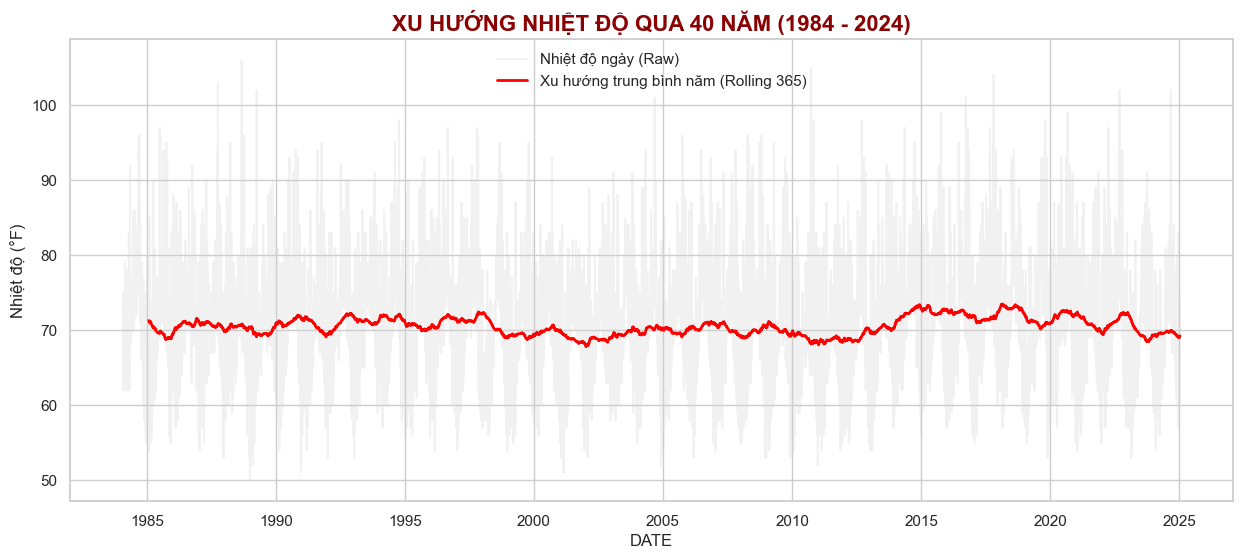

>> NHẬN XÉT: Hãy nhìn đường màu đỏ. Nếu nó đi lên -> Có xu hướng nóng lên toàn cầu.


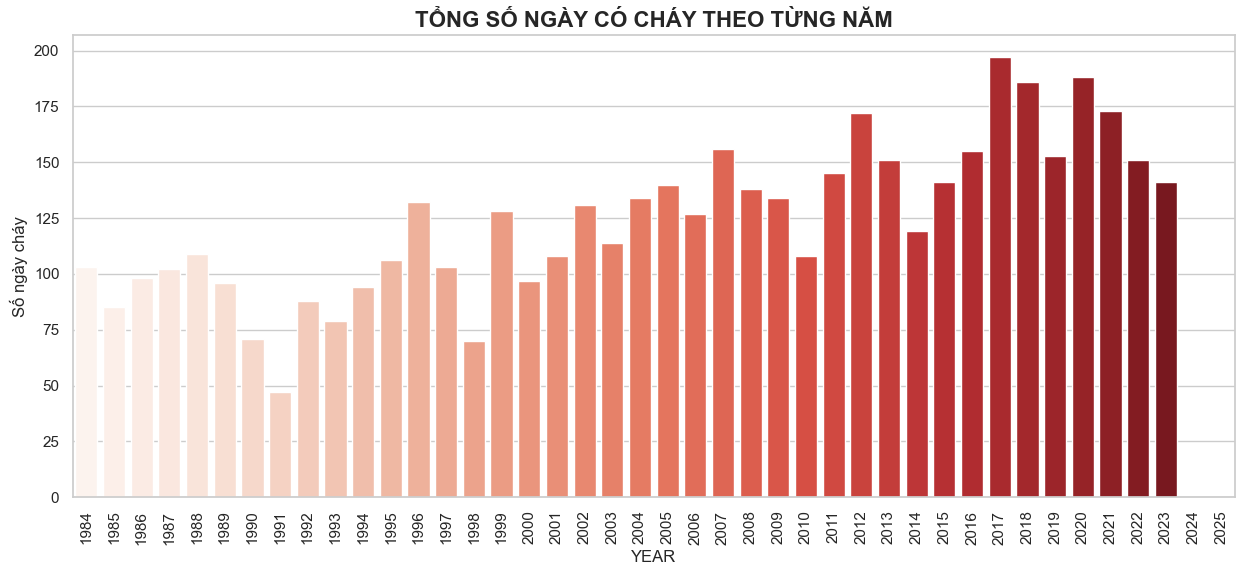

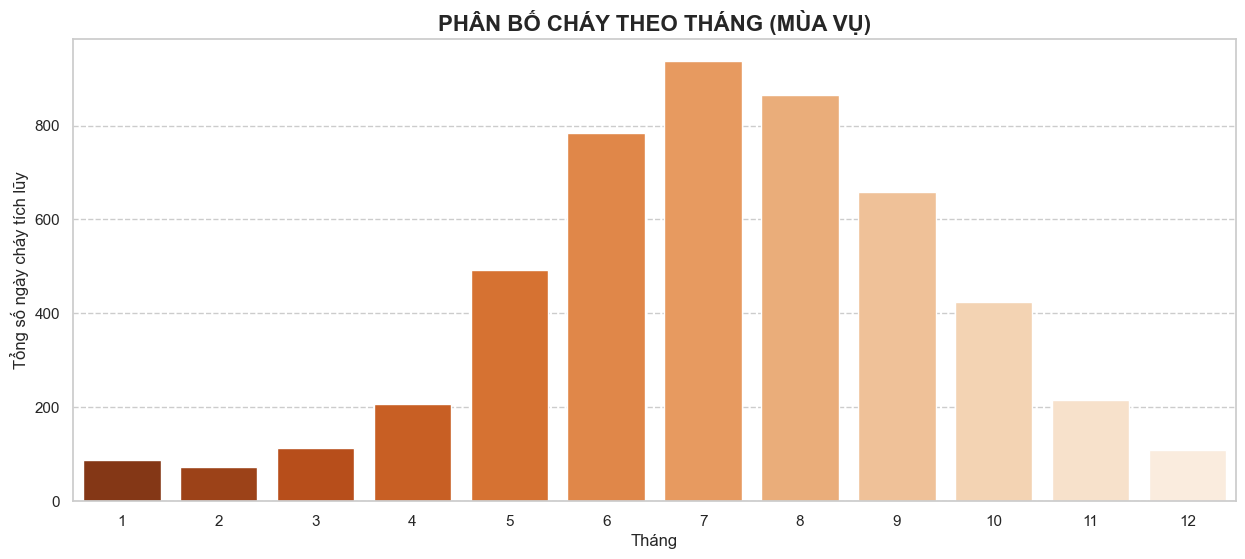

>> NHẬN XÉT MÙA VỤ: Các cột cao nhất chính là 'Mùa Cháy'.
   Dữ liệu này gợi ý ta nên tạo feature 'IS_FIRE_SEASON' cho các tháng đó.


In [17]:
print_section("3. EDA: PHÂN TÍCH XU HƯỚNG & CHUỖI THỜI GIAN (TIME SERIES)")

# Cài đặt giao diện biểu đồ cho đẹp
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)

# ==============================================================================
# BIỂU ĐỒ 1: KIỂM TRA XU HƯỚNG NHIỆT ĐỘ (GLOBAL WARMING CHECK)
# Dùng Rolling Mean (Trung bình trượt) 365 ngày để làm mượt đường biểu diễn
# ==============================================================================
plt.figure()
# Vẽ dữ liệu gốc (mờ nhạt để làm nền)
sns.lineplot(data=df, x="DATE", y="MAX_TEMP", color="lightgray", alpha=0.3, label="Nhiệt độ ngày (Raw)")

# Vẽ đường xu hướng (Làm mượt 365 ngày - Tức là trung bình 1 năm)
# Giúp loại bỏ dao động mùa vụ để nhìn thấy xu hướng dài hạn
df["TEMP_TREND_365"] = df["MAX_TEMP"].rolling(window=365).mean()
sns.lineplot(data=df, x="DATE", y="TEMP_TREND_365", color="red", linewidth=2, label="Xu hướng trung bình năm (Rolling 365)")

plt.title("XU HƯỚNG NHIỆT ĐỘ QUA 40 NĂM (1984 - 2024)", fontsize=16, fontweight='bold', color='darkred')
plt.ylabel("Nhiệt độ (°F)")
plt.legend()
plt.show()

print(">> NHẬN XÉT: Hãy nhìn đường màu đỏ. Nếu nó đi lên -> Có xu hướng nóng lên toàn cầu.")

# ==============================================================================
# BIỂU ĐỒ 2: TỔNG SỐ VỤ CHÁY THEO NĂM (YEARLY TREND)
# Kiểm tra xem tần suất cháy có tăng lên không
# ==============================================================================
# Gom nhóm theo năm và đếm số ngày có cháy
yearly_fire = df.groupby("YEAR")["FIRE_LABEL"].sum().reset_index()

plt.figure()
sns.barplot(data=yearly_fire, x="YEAR", y="FIRE_LABEL", palette="Reds")
plt.title("TỔNG SỐ NGÀY CÓ CHÁY THEO TỪNG NĂM", fontsize=16, fontweight='bold')
plt.xticks(rotation=90) # Xoay năm dọc xuống cho dễ đọc
plt.ylabel("Số ngày cháy")
plt.show()

# ==============================================================================
# BIỂU ĐỒ 3: TÍNH MÙA VỤ (SEASONALITY) - THÁNG NÀO NGUY HIỂM NHẤT?
# ==============================================================================
# Gom nhóm theo tháng và tính tổng số vụ cháy
monthly_fire = df.groupby("MONTH")["FIRE_LABEL"].sum().reset_index()

plt.figure()
sns.barplot(data=monthly_fire, x="MONTH", y="FIRE_LABEL", palette="Oranges_r")
plt.title("PHÂN BỐ CHÁY THEO THÁNG (MÙA VỤ)", fontsize=16, fontweight='bold')
plt.xlabel("Tháng")
plt.ylabel("Tổng số ngày cháy tích lũy")
plt.grid(axis='y', linestyle='--')
plt.show()

print(">> NHẬN XÉT MÙA VỤ: Các cột cao nhất chính là 'Mùa Cháy'.") 
print("   Dữ liệu này gợi ý ta nên tạo feature 'IS_FIRE_SEASON' cho các tháng đó.")

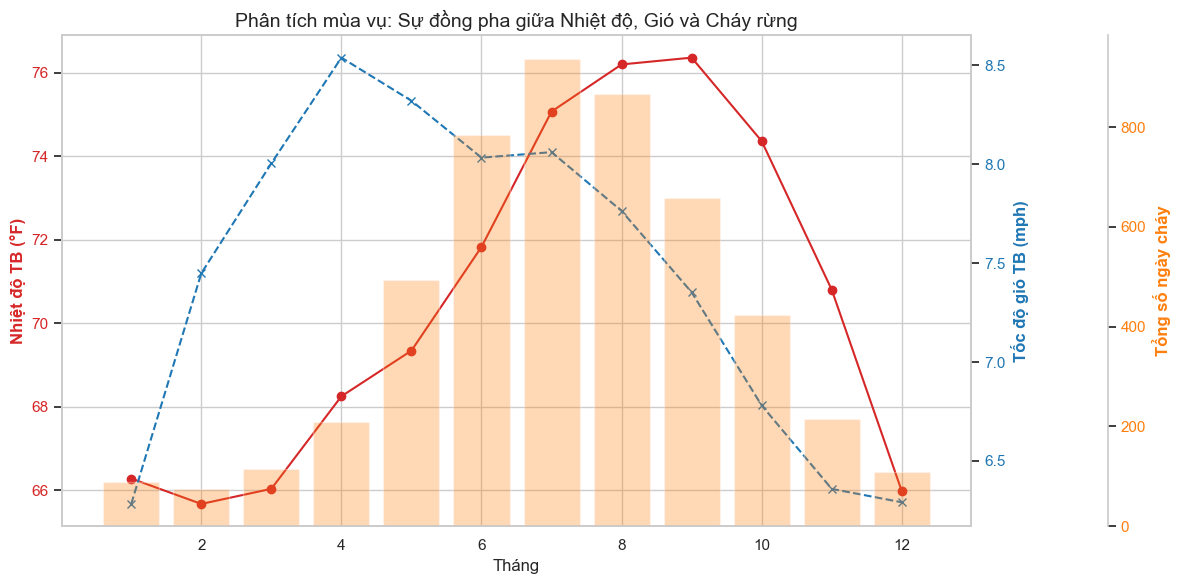

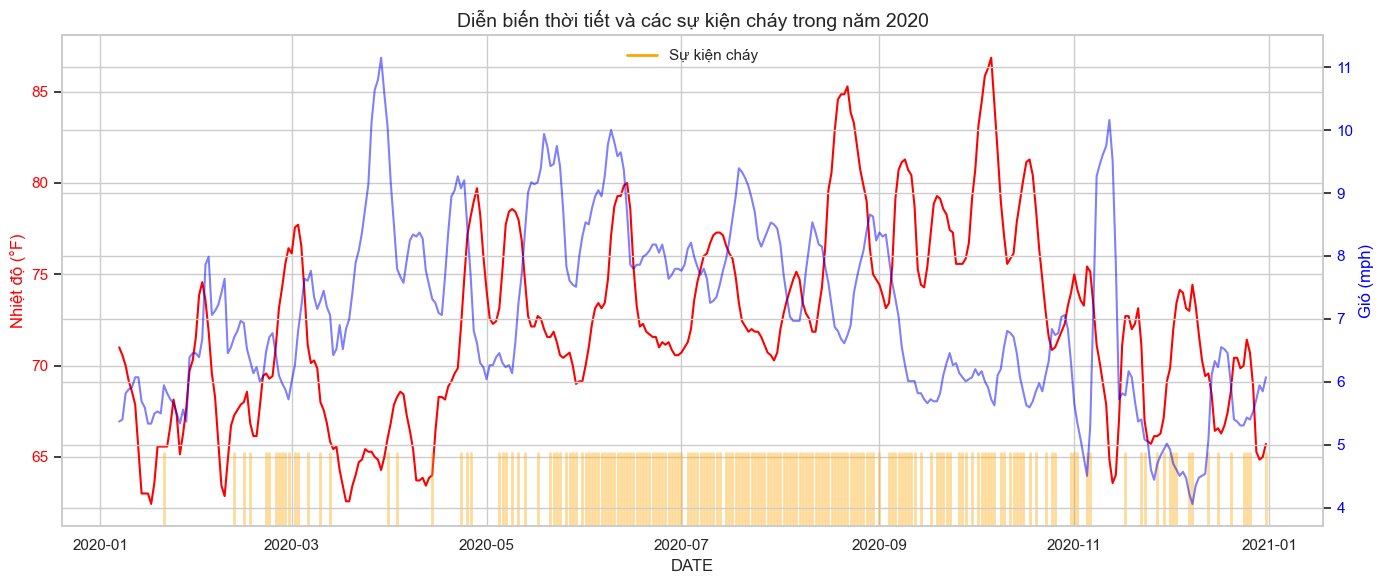

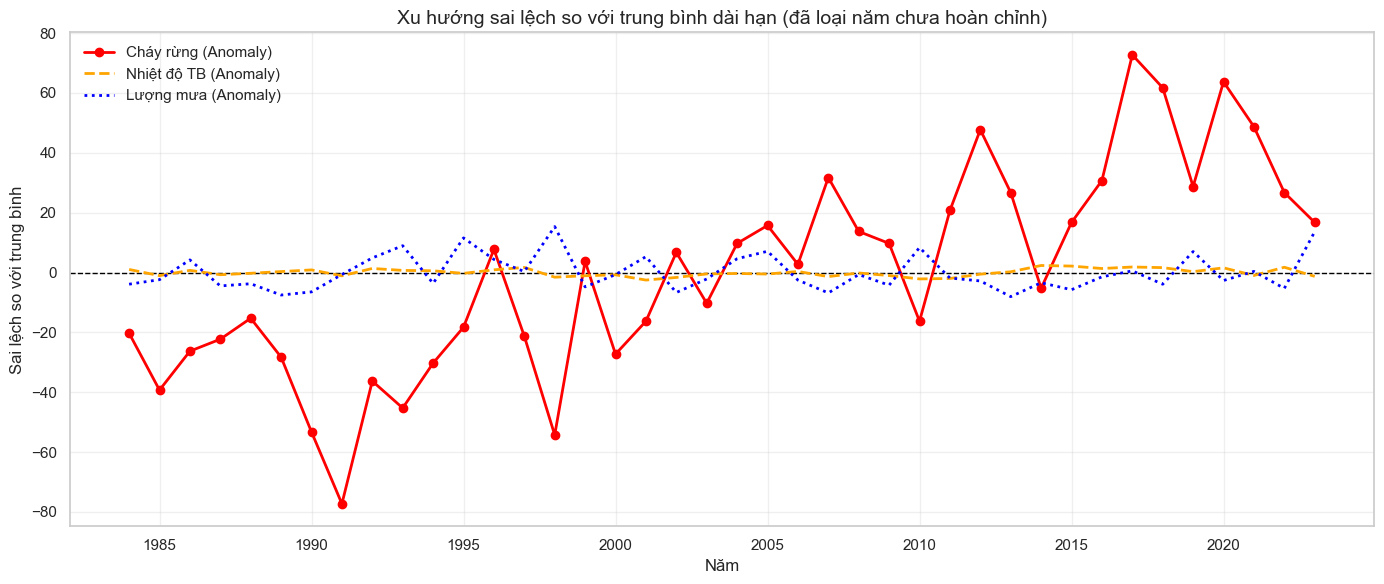

In [18]:

from matplotlib.lines import Line2D

# ===============================
# 1. LOAD & TIỀN XỬ LÝ DỮ LIỆU
# ===============================

df = pd.read_csv(DATA_PATH)

df['DATE'] = pd.to_datetime(df['DATE'])
df['Year'] = df['DATE'].dt.year
df['Month'] = df['DATE'].dt.month

sns.set(style="whitegrid")

# =====================================================
# BIỂU ĐỒ 1: MÙA VỤ ĐA BIẾN (NHIỆT – GIÓ – CHÁY)
# =====================================================

monthly_stats = df.groupby('Month').agg({
    'MAX_TEMP': 'mean',
    'AVG_WIND_SPEED': 'mean',
    'FIRE_START_DAY': 'sum'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Nhiệt độ
ax1.set_xlabel('Tháng')
ax1.set_ylabel('Nhiệt độ TB (°F)', color='tab:red', fontweight='bold')
ax1.plot(monthly_stats['Month'], monthly_stats['MAX_TEMP'],
         color='tab:red', marker='o')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Gió
ax2 = ax1.twinx()
ax2.set_ylabel('Tốc độ gió TB (mph)', color='tab:blue', fontweight='bold')
ax2.plot(monthly_stats['Month'], monthly_stats['AVG_WIND_SPEED'],
         color='tab:blue', linestyle='--', marker='x')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Ngày cháy
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.15))
ax3.set_ylabel('Tổng số ngày cháy', color='tab:orange', fontweight='bold')
ax3.bar(monthly_stats['Month'], monthly_stats['FIRE_START_DAY'],
        color='tab:orange', alpha=0.3)
ax3.tick_params(axis='y', labelcolor='tab:orange')

ax2.grid(False)
ax3.grid(False)

plt.title('Phân tích mùa vụ: Sự đồng pha giữa Nhiệt độ, Gió và Cháy rừng', fontsize=14)
plt.tight_layout()
plt.show()

# =====================================================
# BIỂU ĐỒ 2: CHUỖI THỜI GIAN CHI TIẾT (NĂM ĐIỂN HÌNH)
# =====================================================

year_zoom = 2020

df_sub = (
    df[df['Year'] == year_zoom]
    .sort_values('DATE')
    .set_index('DATE')
)

df_sub['Roll_Temp'] = df_sub['MAX_TEMP'].rolling(7).mean()
df_sub['Roll_Wind'] = df_sub['AVG_WIND_SPEED'].rolling(7).mean()

fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(data=df_sub, x=df_sub.index, y='Roll_Temp',
             color='red', ax=ax)
ax.set_ylabel('Nhiệt độ (°F)', color='red')
ax.tick_params(axis='y', labelcolor='red')

ax2 = ax.twinx()
sns.lineplot(data=df_sub, x=df_sub.index, y='Roll_Wind',
             color='blue', alpha=0.5, ax=ax2)
ax2.set_ylabel('Gió (mph)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

fire_dates = df_sub[df_sub['FIRE_START_DAY'] == True].index
for d in fire_dates:
    ax.axvline(d, color='orange', alpha=0.4, ymin=0, ymax=0.15, linewidth=2)

plt.title(f'Diễn biến thời tiết và các sự kiện cháy trong năm {year_zoom}', fontsize=14)

custom_lines = [Line2D([0], [0], color='orange', lw=2)]
ax.legend(custom_lines, ['Sự kiện cháy'], loc='upper center')

plt.tight_layout()
plt.show()



# =====================================================
# BIỂU ĐỒ 3 (THAY THẾ): ANOMALY PLOT – LOẠI NĂM CUỐI
# =====================================================

# Đếm số tháng mỗi năm
year_month_count = (
    df.groupby('Year')['Month']
    .nunique()
    .reset_index(name='n_months')
)

# Chỉ giữ các năm đủ 12 tháng
valid_years = year_month_count[
    year_month_count['n_months'] == 12
]['Year']

df_full = df[df['Year'].isin(valid_years)]

# Thống kê theo năm
yearly_stats = df_full.groupby('Year').agg({
    'MAX_TEMP': 'mean',
    'PRECIPITATION': 'sum',
    'FIRE_START_DAY': 'sum'
}).reset_index()

# ❌ LOẠI THẲNG NĂM CUỐI CÙNG (dù là 2025 hay gì)
last_year = yearly_stats['Year'].max()
yearly_stats = yearly_stats[yearly_stats['Year'] != last_year]

# ===== Anomaly =====
anomaly = yearly_stats.copy()

anomaly['TEMP_ANOM'] = anomaly['MAX_TEMP'] - anomaly['MAX_TEMP'].mean()
anomaly['RAIN_ANOM'] = anomaly['PRECIPITATION'] - anomaly['PRECIPITATION'].mean()
anomaly['FIRE_ANOM'] = anomaly['FIRE_START_DAY'] - anomaly['FIRE_START_DAY'].mean()

# ===== Plot =====
plt.figure(figsize=(14, 6))
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.plot(anomaly['Year'], anomaly['FIRE_ANOM'],
         color='red', marker='o', linewidth=2, label='Cháy rừng (Anomaly)')

plt.plot(anomaly['Year'], anomaly['TEMP_ANOM'],
         color='orange', linestyle='--', linewidth=2, label='Nhiệt độ TB (Anomaly)')

plt.plot(anomaly['Year'], anomaly['RAIN_ANOM'],
         color='blue', linestyle=':', linewidth=2, label='Lượng mưa (Anomaly)')

plt.title('Xu hướng sai lệch so với trung bình dài hạn (đã loại năm chưa hoàn chỉnh)', fontsize=14)
plt.xlabel('Năm')
plt.ylabel('Sai lệch so với trung bình')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## Cell 3: BIỂU ĐỒ DECOMPOSITION (FIRE_START_DAY)

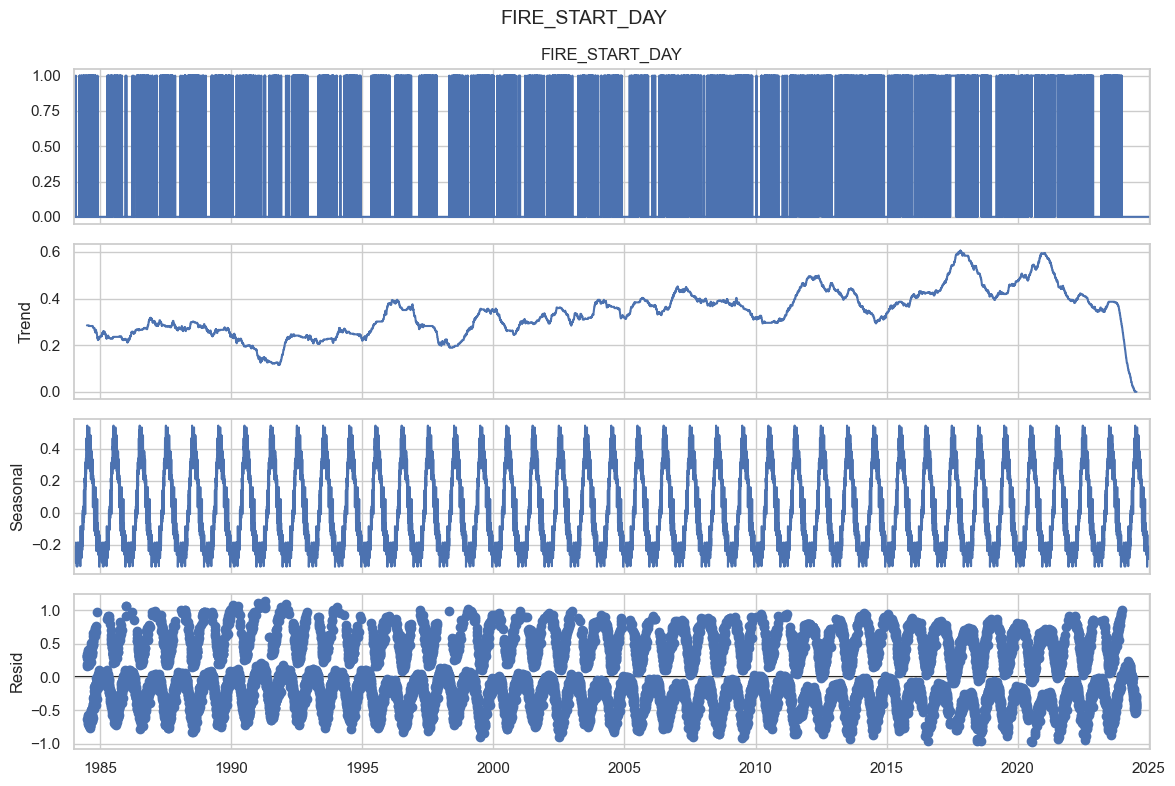

In [19]:


from statsmodels.tsa.seasonal import seasonal_decompose


# ===============================
# 1. CHUẨN BỊ DỮ LIỆU CHUỖI THỜI GIAN
# ===============================

df = pd.read_csv(DATA_PATH)

df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE')

# Set DATE làm index
ts = df.set_index('DATE')['FIRE_START_DAY']

# (Quan trọng) Đảm bảo dữ liệu theo tần suất ngày
ts = ts.asfreq('D')

# Nếu có missing value → fill 0 (phù hợp với FIRE_START_DAY)
# và đảm bảo numeric type cho decomposition
ts = ts.fillna(0).astype(int)

# ===============================
# 2. DECOMPOSITION (CHU KỲ NĂM = 365 NGÀY)
# ===============================

decomposition = seasonal_decompose(
    ts,
    model='additive',   # additive vì biên độ không tăng theo mức
    period=365          # chu kỳ mùa vụ 1 năm
)

# ===============================
# 3. VẼ BIỂU ĐỒ (GIỐNG HÌNH BẠN GỬI)
# ===============================

fig = decomposition.plot()
fig.set_size_inches(12, 8)
fig.suptitle('FIRE_START_DAY', fontsize=14)
plt.tight_layout()
plt.show()


## Cell 4:  ML-EDA & FEATURE SELECTION FOR WILDFIRE (7-DAY)

Dataset shape after preprocessing: (14981, 9)


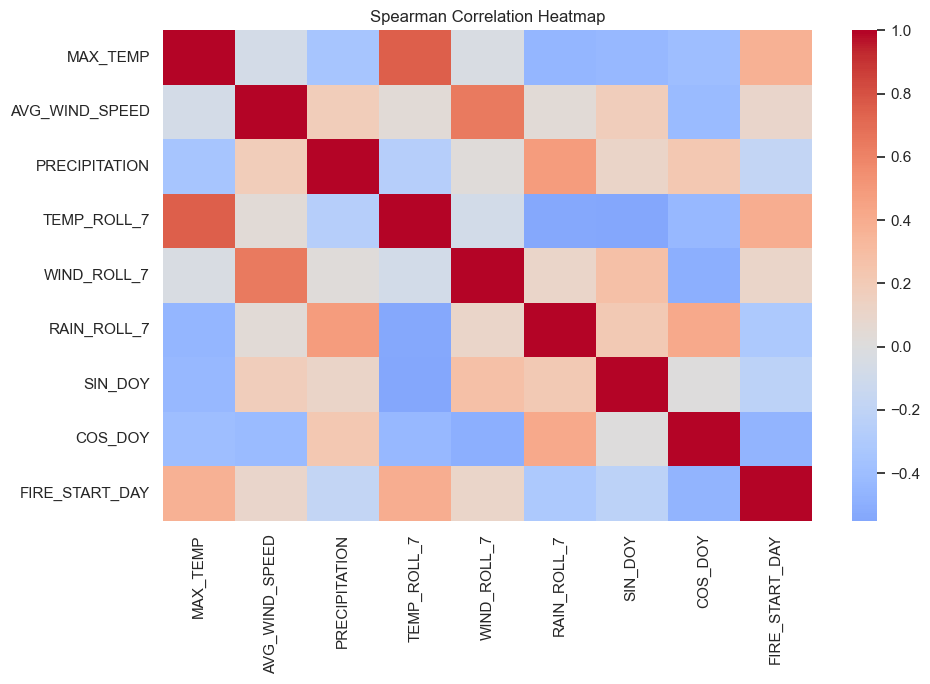


Spearman correlation with FIRE_START_DAY:
COS_DOY          -0.471024
TEMP_ROLL_7       0.388275
MAX_TEMP          0.372648
RAIN_ROLL_7      -0.317783
SIN_DOY          -0.218031
PRECIPITATION    -0.178103
WIND_ROLL_7       0.105710
AVG_WIND_SPEED    0.094235
Name: FIRE_START_DAY, dtype: float64


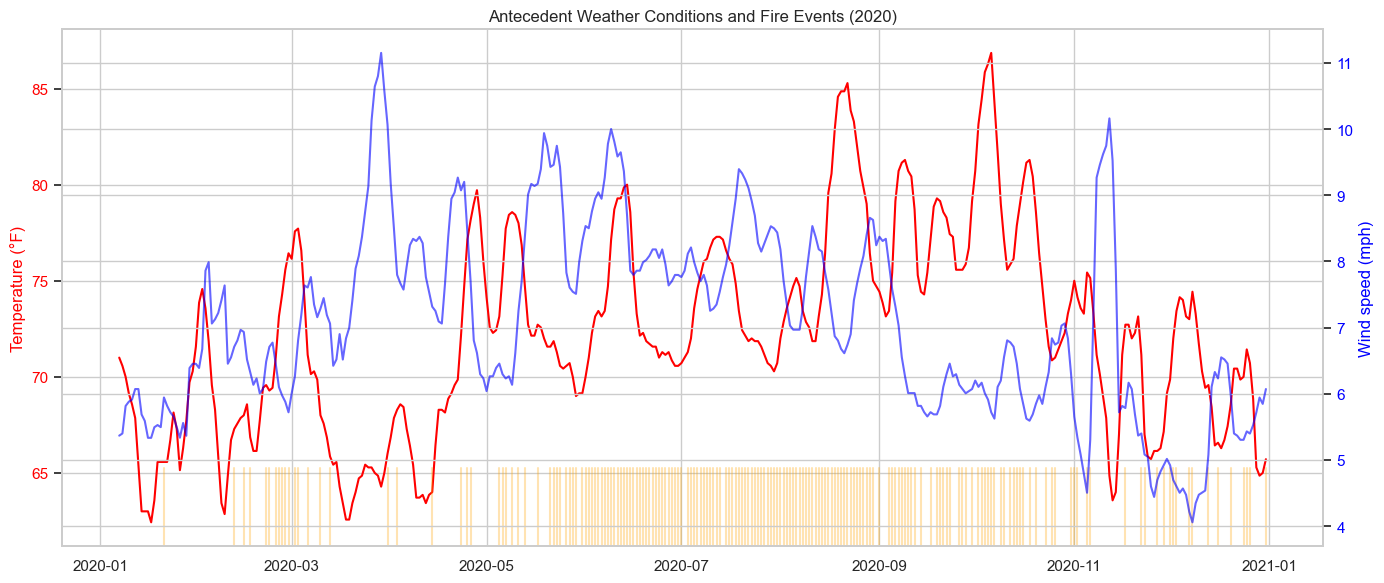


Final selected features:
 - RAIN_ROLL_7
 - TEMP_ROLL_7
 - WIND_ROLL_7
 - MAX_TEMP
 - SIN_DOY
 - COS_DOY

Final ML dataset shape: (14981, 6)


In [20]:
# ======================
# 1. LOAD DATA
# ======================
file_path ="..//Data_clean//CA_Weather_Fire_Dataset_1984-2025_clean.csv"
df = pd.read_csv(file_path)

df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE').set_index('DATE')

TARGET = 'FIRE_START_DAY'

# ======================
# 2. TIME & SEASONAL FEATURES
# ======================
df['DAY_OF_YEAR'] = df.index.dayofyear
df['SIN_DOY'] = np.sin(2 * np.pi * df['DAY_OF_YEAR'] / 365)
df['COS_DOY'] = np.cos(2 * np.pi * df['DAY_OF_YEAR'] / 365)

# ======================
# 3. ROLLING FEATURES (7 DAYS – ANTECEDENT CONDITIONS)
# ======================
df['TEMP_ROLL_7']  = df['MAX_TEMP'].rolling(7).mean()
df['WIND_ROLL_7']  = df['AVG_WIND_SPEED'].rolling(7).mean()
df['RAIN_ROLL_7']  = df['PRECIPITATION'].rolling(7).sum()

# ======================
# 4. REMOVE NON-INFORMATIVE FEATURES
# ======================
DROP_COLS = ['STATION_ID', 'LAT', 'LON']
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# ======================
# 5. AVOID DATA LEAKAGE (SHIFT)
# ======================
FEATURES_EDA = [
    'MAX_TEMP',
    'AVG_WIND_SPEED',
    'PRECIPITATION',
    'TEMP_ROLL_7',
    'WIND_ROLL_7',
    'RAIN_ROLL_7',
    'SIN_DOY',
    'COS_DOY'
]

X = df[FEATURES_EDA].shift(1)
y = df[TARGET]

data = pd.concat([X, y], axis=1).dropna()

print("Dataset shape after preprocessing:", data.shape)

# =====================================================
# 6. ML-EDA STEP 1: HEATMAP (SPEARMAN)
# =====================================================
corr = data.corr(method='spearman')

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=False
)
plt.title('Spearman Correlation Heatmap')
plt.tight_layout()
plt.show()

# Correlation with target
corr_target = (
    corr[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

print("\nSpearman correlation with FIRE_START_DAY:")
print(corr_target)

# =====================================================
# 7. ML-EDA STEP 2: TIME SERIES ANALYSIS (EXAMPLE YEAR)
# =====================================================
YEAR_EXAMPLE = 2020
df_year = df[df.index.year == YEAR_EXAMPLE]

df_year['TEMP_ROLL_7'] = df_year['MAX_TEMP'].rolling(7).mean()
df_year['WIND_ROLL_7'] = df_year['AVG_WIND_SPEED'].rolling(7).mean()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    df_year.index,
    df_year['TEMP_ROLL_7'],
    color='red',
    label='Temperature (7-day mean)'
)
ax1.set_ylabel('Temperature (°F)', color='red')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.plot(
    df_year.index,
    df_year['WIND_ROLL_7'],
    color='blue',
    alpha=0.6,
    label='Wind speed (7-day mean)'
)
ax2.set_ylabel('Wind speed (mph)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Fire events
fire_days = df_year[df_year[TARGET] == 1].index
for d in fire_days:
    ax1.axvline(d, color='orange', alpha=0.3, ymin=0, ymax=0.15)

plt.title(f'Antecedent Weather Conditions and Fire Events ({YEAR_EXAMPLE})')
plt.tight_layout()
plt.show()

# =====================================================
# 8. FINAL FEATURE SELECTION (FROM ML-EDA)
# =====================================================
FINAL_FEATURES = [
    'RAIN_ROLL_7',     # Fuel dryness
    'TEMP_ROLL_7',     # Heat persistence
    'WIND_ROLL_7',     # Fire spread
    'MAX_TEMP',        # Extreme heat signal
    'SIN_DOY',         # Seasonality
    'COS_DOY'
]

X_final = data[FINAL_FEATURES]
y_final = data[TARGET]

print("\nFinal selected features:")
for f in FINAL_FEATURES:
    print(" -", f)

print("\nFinal ML dataset shape:", X_final.shape)

## Cell 5: So sánh feature và đưa ra feature

In [21]:
TARGET = 'FIRE_START_DAY'
CORR_THRESHOLD = 0.05

FEATURES_EDA = [
    'MAX_TEMP',
    'AVG_WIND_SPEED',
    'PRECIPITATION',
    'TEMP_ROLL_7',
    'WIND_ROLL_7',
    'RAIN_ROLL_7',
    'SIN_DOY',
    'COS_DOY'
]

# ---- Tạo lại dataset an toàn leakage ----
X = df[FEATURES_EDA].shift(1)
y = df[TARGET]
data = pd.concat([X, y], axis=1).dropna()

# ---- Tính Spearman correlation ----
corr = data.corr(method='spearman')
corr_target = corr[TARGET].drop(TARGET)

# ---- Feature được chọn theo correlation ----
features_by_corr = {
    f for f in FEATURES_EDA
    if abs(corr_target[f]) >= CORR_THRESHOLD
}

# ---- So sánh ----
eda_features = set(FEATURES_EDA)

features_giu_lai = sorted(eda_features & features_by_corr)
features_loai_bo = sorted(eda_features - features_by_corr)

# ---- HIỂN THỊ SO SÁNH (TIẾNG VIỆT) ----
print("\n===== SO SÁNH ĐẶC TRƯNG =====")

print("\n📌 Danh sách feature ban đầu (EDA):")
for f in FEATURES_EDA:
    print(" -", f)

print("\n✅ feature được GIỮ LẠI sau ML-EDA:")
for f in features_giu_lai:
    print(" -", f)

print("\n❌ feature bị LOẠI BỎ (tương quan yếu với FIRE_START_DAY):")
for f in features_loai_bo:
    print(" -", f)

# ---- LIST FEATURE CUỐI ----
FINAL_FEATURES = features_giu_lai

print("\n🔥 DANH SÁCH feature CUỐI CÙNG (DÙNG CHO MODEL):")
print(FINAL_FEATURES)



===== SO SÁNH ĐẶC TRƯNG =====

📌 Danh sách feature ban đầu (EDA):
 - MAX_TEMP
 - AVG_WIND_SPEED
 - PRECIPITATION
 - TEMP_ROLL_7
 - WIND_ROLL_7
 - RAIN_ROLL_7
 - SIN_DOY
 - COS_DOY

✅ feature được GIỮ LẠI sau ML-EDA:
 - AVG_WIND_SPEED
 - COS_DOY
 - MAX_TEMP
 - PRECIPITATION
 - RAIN_ROLL_7
 - SIN_DOY
 - TEMP_ROLL_7
 - WIND_ROLL_7

❌ feature bị LOẠI BỎ (tương quan yếu với FIRE_START_DAY):

🔥 DANH SÁCH feature CUỐI CÙNG (DÙNG CHO MODEL):
['AVG_WIND_SPEED', 'COS_DOY', 'MAX_TEMP', 'PRECIPITATION', 'RAIN_ROLL_7', 'SIN_DOY', 'TEMP_ROLL_7', 'WIND_ROLL_7']


----------------------------

## 1: THIẾT LẬP MÔ HÌNH VÀ ĐÁNH GIÁ TẦM QUAN TRỌNG CỦA FEATURE

In [22]:
# ==============================================================================
# BƯỚC 1: CHUẨN BỊ DỮ LIỆU & IMPORT (Code đã sửa lỗi kích thước)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, roc_auc_score

# Import các mô hình
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
try:
    from catboost import CatBoostClassifier
except ImportError:
    pass # Xử lý sau nếu chưa cài

# --- XỬ LÝ DỮ LIỆU (Theo code của bạn) ---
# 1. Xử lý biến SEASON (nếu còn là object)
if 'SEASON' in df.columns and df['SEASON'].dtype == 'object':
    le = LabelEncoder()
    df['SEASON'] = le.fit_transform(df['SEASON'])

# 2. Đảm bảo Target là số
target_col = 'FIRE_START_DAY'
if df[target_col].dtype == 'bool':
    df[target_col] = df[target_col].astype(int)

# 3. Loại bỏ các cột không dùng train
# Lưu ý: Xóa cả YEAR, DAY_OF_YEAR nếu không muốn dùng, hoặc giữ lại tùy ý đồ
cols_to_drop = [target_col, 'DATE']
# Kiểm tra xem cột nào tồn tại thì mới drop để tránh lỗi
existing_drop = [c for c in cols_to_drop if c in df.columns]
X = df.drop(columns=existing_drop)
y = df[target_col]

# 4. Chia Train/Test (Time Series Split - 80% đầu, 20% cuối)
n_samples = len(X)
split_idx = int(0.8 * n_samples)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

# 5. Xử lý Missing Value (Impute) - QUAN TRỌNG
imputer = SimpleImputer(strategy='median')
# Fit trên train, transform cả train và test để tránh Data Leakage
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

# 6. CHUẨN HÓA DỮ LIỆU (FIX LỖI CỦA BẠN TẠI ĐÂY)
# Phải tạo scaler mới ngay tại đây để đảm bảo khớp số cột với X_train hiện tại
scaler_std = StandardScaler()
X_train_scaled = pd.DataFrame(scaler_std.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler_std.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"✅ Đã xử lý xong dữ liệu. Kích thước X_train: {X_train.shape}")

# ==============================================================================
# BƯỚC 2: CHẠY 5 MÔ HÌNH & TÍNH FEATURE IMPORTANCE
# ==============================================================================

models = {
    "LogReg": LogisticRegression(max_iter=1000, solver='liblinear', random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(n_estimators=100, verbose=0, random_state=42, allow_writing_files=False)
}

print("\n🚀 Đang chạy huấn luyện và đánh giá độ quan trọng của biến...")
print("-" * 80)

feature_names = X_train.columns.tolist()
# DataFrame chứa importance thô
raw_importance_df = pd.DataFrame(index=feature_names)

for name, model in models.items():
    # A. Huấn luyện
    if name == "LogReg":
        model.fit(X_train_scaled, y_train) # Dùng dữ liệu scaled mới tạo
        y_pred = model.predict(X_test_scaled)
        # Lấy importance (hệ số tuyệt đối)
        imp = np.abs(model.coef_[0])
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        # Lấy importance
        if hasattr(model, 'feature_importances_'):
            imp = model.feature_importances_
        else:
            imp = np.zeros(len(feature_names))
    
    # B. Đánh giá sơ bộ
    f1 = f1_score(y_test, y_pred)
    # Tính AUC an toàn
    try:
        if hasattr(model, "predict_proba"):
            X_eval = X_test_scaled if name == "LogReg" else X_test
            y_prob = model.predict_proba(X_eval)[:, 1]
            auc = roc_auc_score(y_test, y_prob)
        else:
            auc = 0.5
    except:
        auc = 0.5

    print(f"✅ {name:15s} | F1-Score: {f1:.4f} | AUC: {auc:.4f}")
    
    # C. Lưu importance vào bảng
    # (Bây giờ imp và feature_names chắc chắn cùng độ dài)
    raw_importance_df[name] = imp

print("-" * 80)

# ==============================================================================
# BƯỚC 3: XẾP HẠNG VÀ TẠO LIST (CHUẨN KHOA HỌC)
# ==============================================================================

# Dùng MinMaxScaler để đưa về thang 0-1 (dễ so sánh)
scaler_minmax = MinMaxScaler()
importance_scaled = pd.DataFrame(
    scaler_minmax.fit_transform(raw_importance_df), 
    columns=raw_importance_df.columns, 
    index=raw_importance_df.index
)

# Tính điểm trung bình cộng
importance_scaled['Mean_Score'] = importance_scaled.mean(axis=1)
importance_scaled = importance_scaled.sort_values(by='Mean_Score', ascending=False)

# Hiển thị bảng
print("\n📊 BẢNG XẾP HẠNG TẦM QUAN TRỌNG (TOP 10):")
display(importance_scaled.head(10).style.background_gradient(cmap='Greens', subset=['Mean_Score']))

# --- TẠO LIST GIAO & HỢP ---
# 1. Ngưỡng (Threshold)
threshold_val = importance_scaled['Mean_Score'].mean()
print(f"\n🔍 Ngưỡng cắt (Mean Threshold): {threshold_val:.4f}")

# 2. Top 5 Features từ Mô hình
top_5_features_model = importance_scaled.head(5).index.tolist()
print(f"⭐ Top 5 Features từ Mô hình: {top_5_features_model}")

# 3. List EDA (Của bạn)
# Nếu bạn chưa định nghĩa FINAL_FEATURES, hãy uncomment dòng dưới và điền vào
# FINAL_FEATURES = ['MAX_TEMP', 'AVG_WIND_SPEED', ...] 
# Giả sử đã có từ các bước trước:
if 'FINAL_FEATURES' not in locals():
    # List mẫu nếu chưa có
    FINAL_FEATURES = ["AVG_WIND_SPEED", "COS_DOY", "MAX_TEMP", 
                      "PRECIPITATION", "RAIN_ROLL_7", "SIN_DOY", 
                      "TEMP_ROLL_7", "WIND_ROLL_7"]

# 4. Tính Giao và Hợp
list_intersection = list(set(FINAL_FEATURES) & set(top_5_features_model))
list_union = list(set(FINAL_FEATURES) | set(top_5_features_model))

print(f"\n✅ List Giao (Core Features): {list_intersection}")
print(f"✅ List Hợp (Pool for Stepwise): {list_union}")

✅ Đã xử lý xong dữ liệu. Kích thước X_train: (11990, 17)

🚀 Đang chạy huấn luyện và đánh giá độ quan trọng của biến...
--------------------------------------------------------------------------------
✅ LogReg          | F1-Score: 0.7005 | AUC: 0.8161
✅ RandomForest    | F1-Score: 0.6566 | AUC: 0.8146
✅ XGBoost         | F1-Score: 0.6681 | AUC: 0.8072
✅ LightGBM        | F1-Score: 0.6795 | AUC: 0.8163
✅ CatBoost        | F1-Score: 0.6762 | AUC: 0.8220
--------------------------------------------------------------------------------

📊 BẢNG XẾP HẠNG TẦM QUAN TRỌNG (TOP 10):


,LogReg,RandomForest,XGBoost,LightGBM,CatBoost,Mean_Score
COS_DOY,1.000000,0.944045,0.286112,0.744417,0.982371,0.791389
YEAR,0.237699,0.549528,0.167414,1.000000,1.000000,0.590928
MIN_TEMP,0.000000,1.000000,1.000000,0.456576,0.496166,0.590548
TEMP_ROLL_7,0.076325,0.712804,0.111524,0.821340,0.431663,0.430731
SIN_DOY,0.332660,0.527810,0.132438,0.563275,0.386248,0.388486
WIND_TEMP_RATIO,0.298892,0.554236,0.097469,0.722084,0.192437,0.373024
MAX_TEMP,0.036788,0.582495,0.121012,0.523573,0.379336,0.328641
DAY_OF_YEAR,0.026916,0.700939,0.155719,0.568238,0.140265,0.318415
LAGGED_AVG_WIND_SPEED,0.065382,0.531710,0.108168,0.741935,0.111616,0.311762
AVG_WIND_SPEED,0.245974,0.381290,0.087666,0.342432,0.134707,0.238414



🔍 Ngưỡng cắt (Mean Threshold): 0.3171
⭐ Top 5 Features từ Mô hình: ['COS_DOY', 'YEAR', 'MIN_TEMP', 'TEMP_ROLL_7', 'SIN_DOY']

✅ List Giao (Core Features): ['COS_DOY', 'TEMP_ROLL_7', 'SIN_DOY']
✅ List Hợp (Pool for Stepwise): ['SIN_DOY', 'RAIN_ROLL_7', 'MAX_TEMP', 'AVG_WIND_SPEED', 'TEMP_ROLL_7', 'WIND_ROLL_7', 'YEAR', 'COS_DOY', 'PRECIPITATION', 'MIN_TEMP']


## 2. STEPWISE SELECTION & ĐÁNH GIÁ NÂNG CAO

🚀 Đang chạy Stepwise Selection trên 5 mô hình (Cấu hình Heavy Duty)...
   (Quá trình này có thể mất vài phút vì chạy kỹ từng bước)

🔹 Khởi đầu với: ['COS_DOY', 'TEMP_ROLL_7', 'SIN_DOY']
   -> Loss khởi điểm: 0.70399
   -> Đã thêm: YEAR            | Avg Val Loss: 0.57400
   -> Đã thêm: MAX_TEMP        | Avg Val Loss: 0.54061
   -> Đã thêm: RAIN_ROLL_7     | Avg Val Loss: 0.53226
   -> Đã thêm: WIND_ROLL_7     | Avg Val Loss: 0.52584
   -> Đã thêm: AVG_WIND_SPEED  | Avg Val Loss: 0.52714
   -> Đã thêm: PRECIPITATION   | Avg Val Loss: 0.52369
   -> Đã thêm: MIN_TEMP        | Avg Val Loss: 0.52937

🏆 KẾT QUẢ CUỐI CÙNG (Dừng tại bước có Loss thấp nhất)
► Số lượng features tối ưu: 9
► Log Loss thấp nhất: 0.52369
► DANH SÁCH FINAL SET:
['COS_DOY', 'TEMP_ROLL_7', 'SIN_DOY', 'YEAR', 'MAX_TEMP', 'RAIN_ROLL_7', 'WIND_ROLL_7', 'AVG_WIND_SPEED', 'PRECIPITATION']


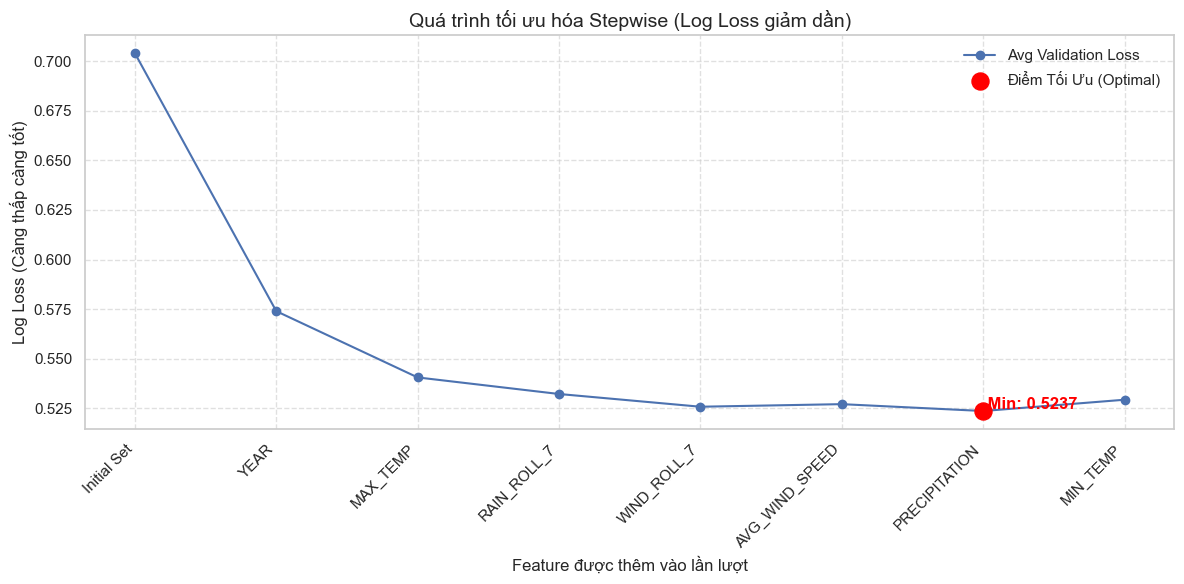

In [23]:
# ==============================================================================
# BƯỚC 3: STEPWISE SELECTION (FORWARD) - TÌM BỘ FEATURE TỐI ƯU NHẤT
# ==============================================================================
from sklearn.metrics import log_loss  # <--- ĐÃ FIX LỖI IMPORT TẠI ĐÂY

print("🚀 Đang chạy Stepwise Selection trên 5 mô hình (Cấu hình Heavy Duty)...")
print("   (Quá trình này có thể mất vài phút vì chạy kỹ từng bước)")

# Hàm đánh giá tập feature: Trả về Log Loss trung bình
def evaluate_feature_set(features, X_tr, y_tr, X_te, y_te, X_tr_sc, X_te_sc):
    losses = []
    for name, model in models.items():
        # QUAN TRỌNG: Chọn dữ liệu đúng cho từng loại mô hình
        if name == "LogReg":
            # LogReg phải dùng dữ liệu Scaled
            model.fit(X_tr_sc[features], y_tr)
            preds = model.predict_proba(X_te_sc[features])[:, 1]
        else:
            # Các mô hình cây dùng dữ liệu gốc (để giữ nguyên bản chất)
            model.fit(X_tr[features], y_tr)
            preds = model.predict_proba(X_te[features])[:, 1]
            
        losses.append(log_loss(y_te, preds))
    return np.mean(losses)

# --- BẮT ĐẦU VÒNG LẶP ---

# 1. Khởi tạo
# Bắt đầu bằng List Giao. Nếu rỗng thì lấy feature mạnh nhất từ mô hình
current_features = list_intersection if list_intersection else [top_5_features_model[0]]
remaining_features = [f for f in list_union if f not in current_features]

history = []

# 2. Đánh giá trạng thái ban đầu
print(f"\n🔹 Khởi đầu với: {current_features}")
initial_loss = evaluate_feature_set(current_features, X_train, y_train, X_test, y_test, X_train_scaled, X_test_scaled)
history.append({'features': list(current_features), 'loss': initial_loss, 'added': 'Initial Set'})
print(f"   -> Loss khởi điểm: {initial_loss:.5f}")

# 3. Vòng lặp thêm dần (Forward Selection)
while remaining_features:
    best_loss_in_step = float('inf')
    best_feature_in_step = None
    
    # Thử thêm từng feature còn lại
    for feature in remaining_features:
        trial_features = current_features + [feature]
        # Gọi hàm đánh giá (truyền cả dữ liệu thường và scaled)
        loss = evaluate_feature_set(trial_features, X_train, y_train, X_test, y_test, X_train_scaled, X_test_scaled)
        
        if loss < best_loss_in_step:
            best_loss_in_step = loss
            best_feature_in_step = feature
    
    # Kiểm tra: Nếu thêm vào mà Loss giảm (tốt hơn) hoặc không tăng quá nhiều thì mới giữ
    # Ở đây ta cứ chạy hết list_union để vẽ biểu đồ, sau đó chọn điểm thấp nhất sau
    current_features.append(best_feature_in_step)
    remaining_features.remove(best_feature_in_step)
    
    history.append({'features': list(current_features), 'loss': best_loss_in_step, 'added': best_feature_in_step})
    print(f"   -> Đã thêm: {best_feature_in_step:15s} | Avg Val Loss: {best_loss_in_step:.5f}")

# ==============================================================================
# KẾT QUẢ & VẼ BIỂU ĐỒ TỐI ƯU HÓA (LOSS CURVE)
# ==============================================================================

# 1. Tìm bước có Loss thấp nhất (Global Min)
best_step = min(history, key=lambda x: x['loss'])
BEST_FINAL_FEATURES = best_step['features']

print("\n" + "="*60)
print(f"🏆 KẾT QUẢ CUỐI CÙNG (Dừng tại bước có Loss thấp nhất)")
print("="*60)
print(f"► Số lượng features tối ưu: {len(BEST_FINAL_FEATURES)}")
print(f"► Log Loss thấp nhất: {best_step['loss']:.5f}")
print(f"► DANH SÁCH FINAL SET:\n{BEST_FINAL_FEATURES}")

# 2. Vẽ biểu đồ quá trình Stepwise (Giảng viên rất thích cái này)
steps = range(len(history))
losses = [x['loss'] for x in history]
labels = [x['added'] for x in history]

plt.figure(figsize=(12, 6))
plt.plot(steps, losses, marker='o', linestyle='-', color='b', label='Avg Validation Loss')

# Đánh dấu điểm thấp nhất
min_idx = losses.index(min(losses))
plt.scatter(min_idx, losses[min_idx], color='red', s=150, zorder=5, label='Điểm Tối Ưu (Optimal)')
plt.text(min_idx, losses[min_idx] + 0.001, f' Min: {losses[min_idx]:.4f}', color='red', fontweight='bold')

plt.xticks(steps, labels, rotation=45, ha='right')
plt.title('Quá trình tối ưu hóa Stepwise (Log Loss giảm dần)', fontsize=14)
plt.ylabel('Log Loss (Càng thấp càng tốt)')
plt.xlabel('Feature được thêm vào lần lượt')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
print_section("7. ĐÁNH GIÁ HOLDOUT (TEST CUỐI CHUỖI)")

from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Bộ mô hình đánh giá cuối
best_models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "LogReg": LogisticRegression(max_iter=1000, solver='liblinear', random_state=42),
    "CatBoost": CatBoostClassifier(n_estimators=100, verbose=0, random_state=42, allow_writing_files=False),
    "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
}

# 2. Lấy đúng bộ feature tối ưu từ stepwise
X_train_final = X_train[BEST_FINAL_FEATURES].copy()
X_test_final = X_test[BEST_FINAL_FEATURES].copy()

X_train_scaled_final = X_train_scaled[BEST_FINAL_FEATURES].copy()
X_test_scaled_final = X_test_scaled[BEST_FINAL_FEATURES].copy()

# 3. Hàm tìm ngưỡng tối ưu theo F1
def tim_threshold_toi_uu(y_true, y_prob):
    cac_nguong = np.arange(0.30, 0.71, 0.01)

    threshold_tot_nhat = 0.50
    f1_tot_nhat = -1

    for nguong in cac_nguong:
        y_pred = (y_prob >= nguong).astype(int)
        diem_f1 = f1_score(y_true, y_pred, zero_division=0)

        if diem_f1 > f1_tot_nhat:
            f1_tot_nhat = diem_f1
            threshold_tot_nhat = nguong

    return threshold_tot_nhat, f1_tot_nhat

# 4. Hàm đánh giá từng mô hình
def evaluate_model(name, model, X_te, y_te):
    model_copy = clone(model)

    if name == "LogReg":
        model_copy.fit(X_train_scaled_final, y_train)
        y_prob = model_copy.predict_proba(X_test_scaled_final)[:, 1]
    else:
        model_copy.fit(X_train_final, y_train)
        y_prob = model_copy.predict_proba(X_test_final)[:, 1]

    threshold_best, _ = tim_threshold_toi_uu(y_te, y_prob)
    y_pred = (y_prob >= threshold_best).astype(int)

    return {
        "model": name,
        "threshold*": round(threshold_best, 2),
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1": f1_score(y_te, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_te, y_prob)
    }

# 5. Chạy đánh giá holdout
holdout_reports = []

for name, model in best_models.items():
    rep = evaluate_model(name, model, X_test_final, y_test)
    holdout_reports.append(rep)

holdout_df = pd.DataFrame(holdout_reports).sort_values("f1", ascending=False)

holdout_df = holdout_df[["model", "threshold*", "accuracy", "precision", "recall", "f1", "roc_auc"]]

holdout_df["threshold*"] = holdout_df["threshold*"].round(2)
holdout_df["accuracy"] = holdout_df["accuracy"].round(6)
holdout_df["precision"] = holdout_df["precision"].round(6)
holdout_df["recall"] = holdout_df["recall"].round(6)
holdout_df["f1"] = holdout_df["f1"].round(6)
holdout_df["roc_auc"] = holdout_df["roc_auc"].round(6)

display(holdout_df)


7. ĐÁNH GIÁ HOLDOUT (TEST CUỐI CHUỖI)



,model,threshold*,accuracy,precision,recall,f1,roc_auc
1,LogReg,0.38,0.740160,0.636187,0.818182,0.715797,0.814906
0,RandomForest,0.30,0.732488,0.625712,0.824020,0.711303,0.814768
4,LightGBM,0.30,0.735157,0.633136,0.803169,0.708088,0.821765
2,CatBoost,0.34,0.741828,0.649332,0.770642,0.704805,0.822469
3,XGBoost,0.30,0.736157,0.643258,0.763970,0.698437,0.810322


## 3-Matrix biểu đồ

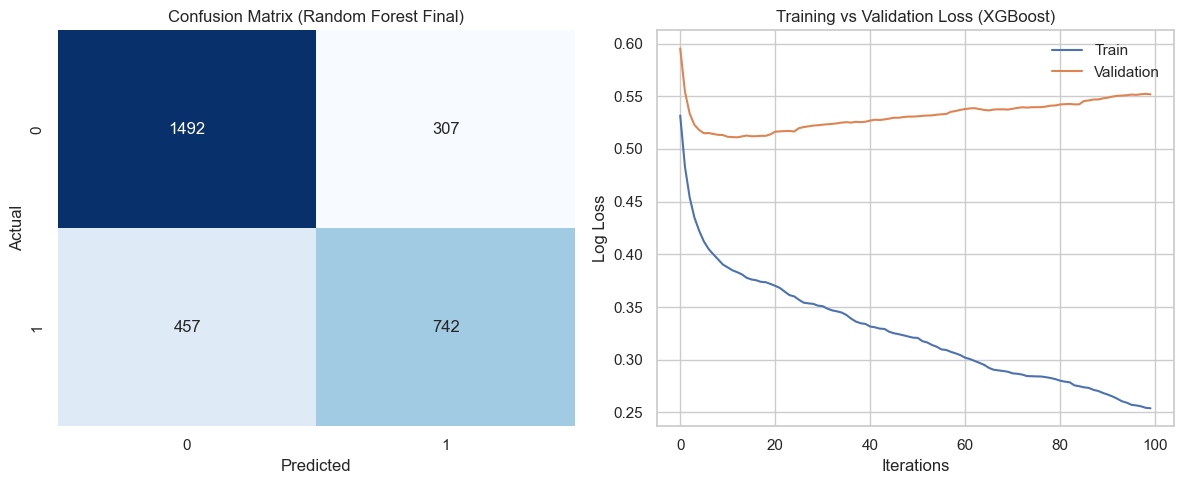

Hoàn tất phân tích nâng cao!


In [25]:

# 1. Confusion Matrix (Dùng Random Forest làm đại diện)
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_train[BEST_FINAL_FEATURES], y_train)
y_pred = rf_final.predict(X_test[BEST_FINAL_FEATURES])
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 5))

# Plot Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Random Forest Final)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# 2. Training vs Validation Loss Curve (Dùng XGBoost/Catboost đại diện để thấy quá trình học)
# Lưu ý: RF không có staged_predict loss trực quan như Boosting
xgb_final = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_final.fit(X_train[BEST_FINAL_FEATURES], y_train, eval_set=[(X_train[BEST_FINAL_FEATURES], y_train), (X_test[BEST_FINAL_FEATURES], y_test)], verbose=False)

results = xgb_final.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.subplot(1, 2, 2)
plt.plot(x_axis, results['validation_0']['logloss'], label='Train')
plt.plot(x_axis, results['validation_1']['logloss'], label='Validation')
plt.legend()
plt.ylabel('Log Loss')
plt.xlabel('Iterations')
plt.title('Training vs Validation Loss (XGBoost)')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Hoàn tất phân tích nâng cao!")